In [1]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))
import importlib
import utils 
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_template_from_geneset
from utils.dna import Genes, create_template_from_genes
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
ROOT_DIR = Path(__name__).resolve().parents[2]
ROOT_DIR

PosixPath('/Users/maciej.czyjt/private/prompt2avatar')

# Prepare data for trainig 

In [3]:
DATASET_NAME = 'easyv2_geneset_embeddings'
DATASET_DIR = DATA_DIR / DATASET_NAME
EXPERIMENT_DIR = ROOT_DIR / 'experiments' / DATASET_NAME
geneset = ProcessedDataset(DATASET_DIR)

100%|██████████| 1/1 [00:00<00:00, 52.97it/s]


In [14]:
dna_dir = Path("/Users/maciej.czyjt/private/prompt2avatar/data/easyv2_geneset/dna")
dnas = [(dna_dir / Path(p).name.replace("png", "txt")).read_text() for p in geneset.paths]

In [16]:
np.save(DATASET_DIR / "dnas.npy", np.array(dnas))

In [17]:
import utils.dataset 
import models.mlp
importlib.reload(utils.dataset)
importlib.reload(models.mlp)
from utils.dataset import get_raw_dataset
# train test split for combined features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA 


GENESET = "easyv2"
FEATURES = "arcface-r100"
images = geneset.alligned_images
X, Y = get_raw_dataset(GENESET, FEATURES)
X_train, X_test, Y_train, Y_test, medium_images_train, medium_images_test = train_test_split(X, Y, images, test_size=0.1, random_state=42)
pca = PCA(0.95).fit(Y_train)
Y_train = pca.transform(Y_train)
Y_test = pca.transform(Y_test)
scaler_x = MinMaxScaler()
scaler_x.fit(X_train)
X_train_sc = scaler_x.transform(X_train)
X_test_sc = scaler_x.transform(X_test)
print(f"shape of dataset: {X.shape}, {Y.shape}")



100%|██████████| 1/1 [00:00<00:00, 103.93it/s]


shape of dataset: (30315, 24), (30315, 512)


# Models

In [18]:
pd.set_option('display.max_rows', None)
from sklearn.metrics import r2_score

def error_per_features(Y_test, Y_pred, gene_names):
    # comput rmse per feature in Y
    rmse_per_feature = np.sqrt(np.mean((Y_test - Y_pred)**2, axis=0))
    std_per_feature = np.std(Y_test, axis=0)
    r2 = r2_score(Y_test, Y_pred,  multioutput='raw_values')
    tuples =  list(zip(range(len(gene_names)), sorted(gene_names), rmse_per_feature, std_per_feature, r2))
    tuples = sorted(tuples, key=lambda x: x[4], reverse=True)
    df = pd.DataFrame(tuples, columns=["index", "gene", "rmse", "std", "r2"])
    df.set_index("index", inplace=True)
    # add column with R2 metric 
    # dipaly all rows of this df 
    return df

## XGboost

In [8]:
# train xgboost model
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from wandb.integration.xgboost import WandbCallback
import wandb 

xgb_model_path = EXPERIMENT_DIR / 'xgb_model.pkl'
if xgb_model_path.exists():
    with open(xgb_model_path, 'rb') as f:
        model = pickle.load(f)
else:
    xgb_model_path.parent.mkdir(parents=True, exist_ok=True)
    evalset = [(Y_train, X_train), (Y_test, X_test)]
    model = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 1, learning_rate = 0.1,
                    max_depth = 8, n_estimators = 1000)
    
    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["xgboost", GENESET], group="xgboost" + GENESET
    ) as wandb_run:
        model.fit(Y_train, X_train, eval_metric='rmse', eval_set=evalset, verbose=True, callbacks=[WandbCallback(log_model=True)])
        with open(xgb_model_path, 'wb') as f:
            pickle.dump(model, f)

X_pred = model.predict(Y_test)
rmse = np.sqrt(mean_squared_error(X_test, X_pred))
r2 = r2_score(X_test, X_pred, multioutput='uniform_average')
mae = mean_absolute_error(X_test, X_pred, multioutput='uniform_average')
print("RMSE: %f  R2: %f  MAE:  %f" % (rmse, r2, mae))

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: czyjtu. Use `wandb login --relogin` to force relogin


/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `callbacks` in `fit` method is deprecated for better compatibility with scikit-learn, use `callbacks` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:0.17268	validation_1-rmse:0.17332
[1]	validation_0-rmse:0.15884	validation_1-rmse:0.16019
[2]	validation_0-rmse:0.14641	validation_1-rmse:0.14847
[3]	validation_0-rmse:0.13521	validation_1-rmse:0.13803
[4]	validation_0-rmse:0.12515	validation_1-rmse:0.12865
[5]	validation_0-rmse:0.11607	validation_1-rmse:0.12026
[6]	validation_0-rmse:0.10795	validation_1-rmse:0.11283
[7]	validation_0-rmse:0.10062	validation_1-rmse:0.10625
[8]	validation_0-rmse:0.09405	validation_1-rmse:0.10039
[9]	validation_0-rmse:0.08812	validation_1-rmse:0.09520
[10]	validation_0-rmse:0.08278	validation_1-rmse:0.09058
[11]	validation_0-rmse:0.07797	validation_1-rmse:0.08650
[12]	validation_0-rmse:0.07359	validation_1-rmse:0.08285
[13]	validation_0-rmse:0.06966	validation_1-rmse:0.07962
[14]	validation_0-rmse:0.06611	validation_1-rmse:0.07674
[15]	validation_0-rmse:0.06290	validation_1-rmse:0.07421
[16]	validation_0-rmse:0.05998	validation_1-rmse:0.07196
[17]	validation_0-rmse:0.05734	validation

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
validation_0-rmse,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-rmse,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,999


RMSE: 0.043223  R2: 0.904353  MAE:  0.031281


In [11]:
save_predicitons(X_pred, scaler_x, EXPERIMENT_DIR / 'predicted_dnas_xgb', GENESET)

100%|██████████| 1/1 [00:00<00:00, 72.03it/s]


## Random Forest

In [1]:
# run random forest regressor 
from sklearn.ensemble import RandomForestRegressor

random_forest_path = EXPERIMENT_DIR / 'random_forest_model.pkl'
if random_forest_path.exists():
    with open(random_forest_path, 'rb') as f:
        model = pickle.load(f)
else:
    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["decision_trees", GENESET], group="decision_trees" + GENESET
    ) as wandb_run:
        random_forest_path.parent.mkdir(parents=True, exist_ok=True)
        model = RandomForestRegressor(n_estimators=500, max_depth=8) 
        model.fit(Y_train, X_train)
        with open(random_forest_path, 'wb') as f:
            pickle.dump(model, f)
        
        wandb.sklearn.plot_regressor(model, Y_train, Y_test, X_train, X_test, model_name="RandomForestRegressor")
        
X_pred = model.predict(Y_test)
rmse = np.sqrt(mean_squared_error(X_test, X_pred))
r2 = r2_score(X_test, X_pred, multioutput='uniform_average')
mae = mean_absolute_error(X_test, X_pred, multioutput='uniform_average')
print("RMSE: %f  R2: %f  MAE:  %f" % (rmse, r2, mae))
save_predicitons(X_pred, scaler_x, EXPERIMENT_DIR / 'predicted_dnas_rf', GENESET)

NameError: name 'EXPERIMENT_DIR' is not defined

## MLP

In [19]:
import utils.dataset 
import models.mlp
importlib.reload(utils.dataset)
importlib.reload(models.mlp)
from utils.dataset import get_raw_dataset
# train test split for combined features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from models.mlp import MLP, train_mlp
import torch.nn as nn 


class DNARegressorV2(nn.Module):
    INFO = "dropout + batchnorm"
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressorV2, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.layers.append(nn.BatchNorm1d(hidden_sizes[i]))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(0.5))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer(x)
        x = self.layers[-1](x)
        return x

mlp_model = train_mlp(
    X_train_sc,
    X_test_sc,
    Y_train,
    Y_test,
    medium_images_test,
    DATA_DIR / f"../experiments/{GENESET}_geneset/mlp-v2/{FEATURES}",
    GENESET,
    feature_names=FEATURES,
    force=False,
    model_raw=DNARegressorV2(input_size=Y_train.shape[1], output_size=X_train.shape[1], hidden_sizes=[512, 512, 512]),
    model_raw_name="mlp+dropout+batchnorm",
    lr=1e-3,
)

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: czyjtu. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:396: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name  | Type           | Params | Mode 
-------------------------------------------------
0 | model | DNARegressorV2 | 549 K  | train
-------------------------------------------------
549 K     Trainable params
0         Non-trainable params
549 K     Total params
2.200     Total estimated model params size (MB)


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 34: 100%|██████████| 214/214 [00:03<00:00, 68.13it/s, v_num=6f5v, train_loss_step=1.260, val_loss=0.0247, train_loss_epoch=0.0262, RMSE=0.157, Scaled RMSE=0.157, MAE=0.113, R2=0.0138]  


MAE,█▃▃▂▁▁▁
R2,▁▆▇▇███
RMSE,█▃▃▂▂▁▁
Scaled RMSE,█▃▃▂▂▁▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss_epoch,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,█▃▂▂▂▂▃▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
val_loss,█▃▃▄▅▃▅▂▃▂▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
MAE,0.11343
R2,0.01376


In [10]:
import torch as th 
mlp_model.eval()
save_predicitons(mlp_model.forward(th.tensor(Y_test).float()).detach().numpy(), scaler_x, EXPERIMENT_DIR / FEATURES / 'predicted_dnas_mlp', GENESET) 

100%|██████████| 7/7 [00:00<00:00, 73.99it/s]


# Ck vs Ck Face similarities

In [9]:
def get_cosine_similarity_matrix(X, X_pred):
    X = X / np.linalg.norm(X, axis=1)[:, None]
    X_pred = X_pred / np.linalg.norm(X_pred, axis=1)[:, None]
    return X @ X_pred.T

def display_random_pair(images, pred_images, i):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(images[i])
    ax[1].imshow(pred_images[i])
    plt.show()

mlp_pred_dataset = ProcessedDataset(EXPERIMENT_DIR / FEATURES / 'predicted_dnas_mlp_embeddings')
indicies_with_detected_faces = [int(p.split('_')[-1].split('.')[0]) for p in mlp_pred_dataset.paths]
test_images_with_faces = [medium_images_test[i] for i in indicies_with_detected_faces]

100%|██████████| 5/5 [00:00<00:00, 803.48it/s]


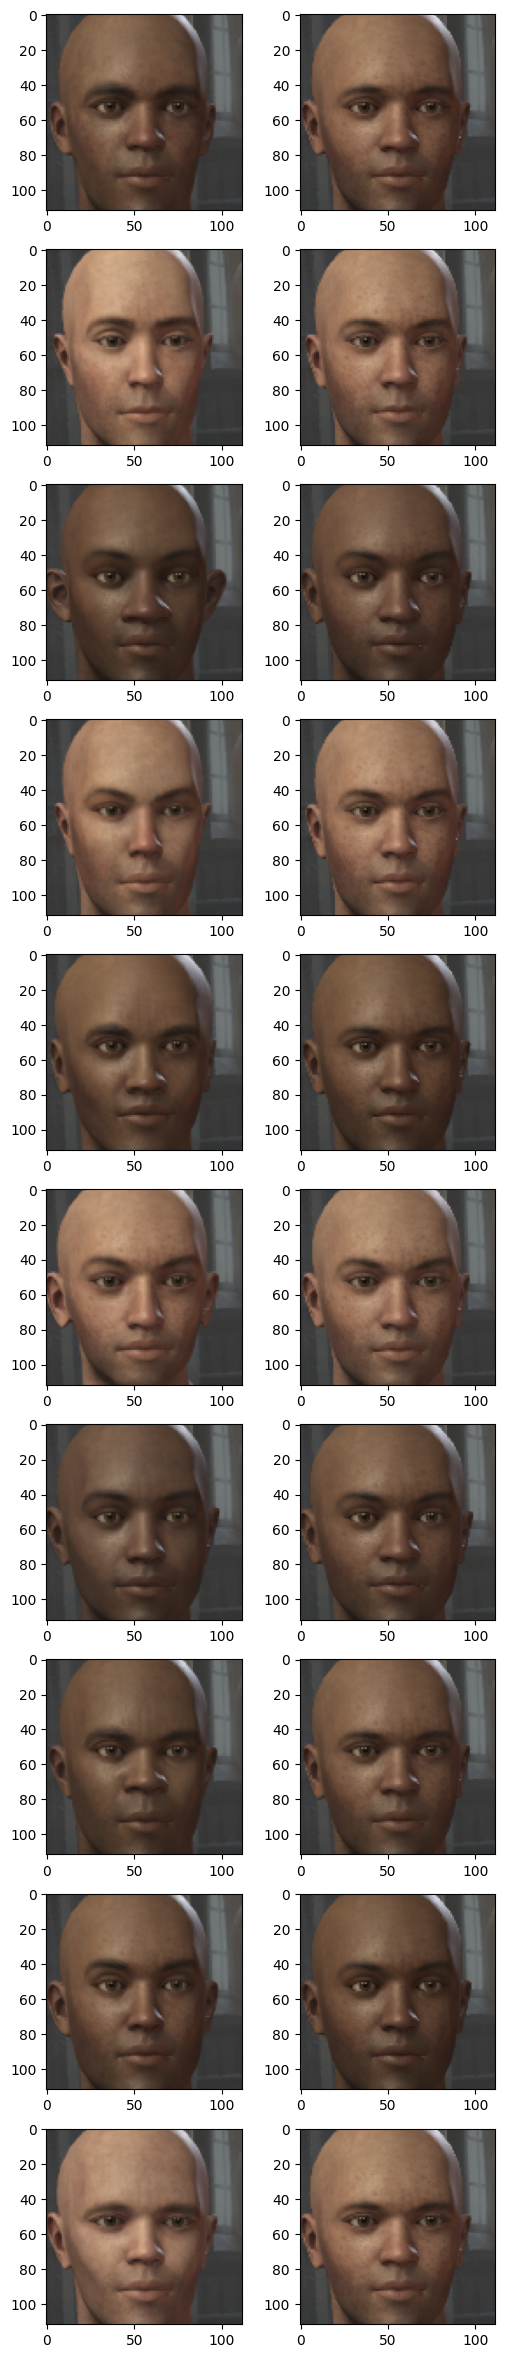

In [10]:
# get grid of imagse 10 x 2 

fig, axs = plt.subplots(10, 2, figsize=(6, 30))
for j, i in enumerate(range(100, 200, 10)):
    img = test_images_with_faces[i]
    pred_img = mlp_pred_dataset.alligned_images[i]
    axs[j, 0].imshow(img)
    axs[j, 1].imshow(pred_img)
plt.show()

# for i in range(100, 200, 10): display_random_pair(test_images_with_faces, mlp_pred_dataset.alligned_images, i)

In [9]:
X_pred.shape, X_real.shape

((3034, 512), (3034, 13))

In [15]:
from sklearn.model_selection import train_test_split
X2, Y2 = get_raw_dataset(GENESET, "arcface-r100")
X_train2, X_test2, Y_train2, Y_test2, medium_images_train2, medium_images_test2 = train_test_split(X2, Y2, images, test_size=0.1, random_state=42)

# mean consine similarity between predicted and true embeddings
Y_pred_faces_features = mlp_pred_dataset.model2normalized_embeddings["arcface-r100"]
Y_real_faces_features = Y_test2[indicies_with_detected_faces]
assert Y_pred_faces_features.shape == Y_real_faces_features.shape
cosine_sim = [x_true @ x_pred for x_true, x_pred in zip(Y_real_faces_features, Y_pred_faces_features)]
np.mean(cosine_sim)

100%|██████████| 7/7 [00:00<00:00, 46.26it/s]


0.05106557

In [30]:
from utils.dataset import MEDIUIM_GENESET_GENES
import torch as th 
mlp_model = mlp_model.eval().to("cpu")
X_pred_mlp = mlp_model.forward(th.tensor(Y_test).float()).detach().numpy()
df_error = error_per_features(X_test_sc, X_pred_mlp, MEDIUIM_GENESET_GENES)
df_error

,gene,rmse,std,r2
index,,,,
32,skin_color[0],0.187781,0.334923,0.685648
24,gene_jaw_angle.jaw_angle_pos,0.097754,0.170123,0.669825
18,gene_eye_distance.eye_distance_pos,0.114346,0.178370,0.589041
9,gene_bs_forehead_brow_inner_height.forehead_br...,0.124655,0.191944,0.578237
16,gene_chin_width.chin_width_pos,0.104933,0.152397,0.525899
10,gene_bs_forehead_brow_outer_height.forehead_br...,0.169088,0.242599,0.514211
12,gene_bs_nose_nostril_width.nose_nostril_width_pos,0.133281,0.189351,0.504549
25,gene_jaw_height.jaw_height_pos,0.149387,0.205371,0.470887
27,gene_mouth_height.mouth_height_pos,0.098209,0.134272,0.465031


In [39]:
# r2 error per gene group 
cat2color = {
    "skin": "red",
    "eye": "blue",
    "_chin": "green",
    "_forehead": "yellow",
    "_head": "purple",
    "_mouth": "orange",
    "_neck": "black",
    "_cheek": "brown",
    "_ear": "pink",
    "_nose": "gray",
    "body_type": "cyan",
    "other": "black",
    "_jaw": "magenta",
}
def get_group(gene):
    for cat in cat2color:
        if cat in gene:
            return cat
    return "other"

df_error["group"] = df_error["gene"].apply(get_group).astype("category")

df_error.groupby("group").mean(True).sort_values("r2", ascending=False)

/var/folders/j2/83k2pfk133n_vkpjy9xj72c00000gn/T/ipykernel_75777/1313201527.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_error.groupby("group").mean(True).sort_values("r2", ascending=False)


,rmse,std,r2
group,,,
skin,0.191291,0.281614,0.513020
_forehead,0.141153,0.198259,0.479027
_nose,0.149233,0.195899,0.419090
_jaw,0.123216,0.167075,0.397114
_chin,0.114030,0.143172,0.327907
_mouth,0.119899,0.145620,0.321054
eye,0.119691,0.142089,0.213843
_head,0.105504,0.116263,0.136777
_neck,0.146070,0.170144,0.134052


# Real faces test

In [46]:
from thirdparty.recognition.arcface_torch.backbones import get_model # source:https://github.com/deepinsight/insightface/tree/master
import insightface
from insightface.utils import face_align
import torch as th 
import torchvision.transforms as VT
import numpy as np 
import warnings 
from tqdm import tqdm 
from pathlib import Path 
import matplotlib.pyplot as plt
from PIL import Image

def display_image(img: np.ndarray):
    plt.imshow(img)
    plt.axis("off")
    plt.show()

class FaceDetector:
    def __init__(self):
        self.insight_face_app = insightface.app.FaceAnalysis(name="antelopev2", allowed_modules=["detection"])
        self.insight_face_app.prepare(ctx_id = 0, det_thresh = 0.1)

    def __call__(self, img: np.ndarray):
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        face = self.insight_face_app.get(img)[0]
        aimg = face_align.norm_crop(img, landmark=face.kps, image_size=112)
        return aimg
    
def allign_faces(images: np.ndarray, detector: FaceDetector, labels: list[str]) -> tuple[np.ndarray["X", float], np.ndarray["y", str]]:
    def handle_no_face_detected(img: np.ndarray, i: int) -> np.ndarray | None:
        try:
            return detector(img)
        except IndexError:
            warnings.warn(f"No face detected in image {i}")
            return None
    
    alligned_images = [handle_no_face_detected(img, i) for i, img in tqdm(list(enumerate(images)))]
    filtered_images, filtered_labels = zip(*[(img, label) for img, label in zip(alligned_images, labels) if img is not None])    
    return np.array(filtered_images), np.array(filtered_labels)


def _load_insightface_model(weights_path: str) -> th.nn.Module:
    resnet_version = weights_path.split("_")[-1].split(".")[0]
    model = get_model(resnet_version)
    model.load_state_dict(th.load(weights_path, map_location=th.device('cpu')))
    model = model.eval()
    return model

In [47]:
REAL_IMG_PATHS = DATA_DIR / 'ck_faces_dataset' 
real_images_paths = [
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/brad_pit/006_aee8d88b.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/cersei_lannister/004_afbbdf8a.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/dr_house/002_3299cc32.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/freddie_mercury/002_19e97a8c.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/kanye_west/image.png",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/walter_white/002_7ff310e8.jpg"
]
    
real_images = [np.array(Image.open(p)) for p in real_images_paths]
detector = FaceDetector()
alligned_real_images, _ = allign_faces(real_images, detector, ["brad_pit", "cersei_lannister", "dr_house", "freddie_mercury", "kanye_west", "walter_white"])

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/glintr100.onnx recognition
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


100%|██████████| 6/6 [00:00<00:00,  9.74it/s]


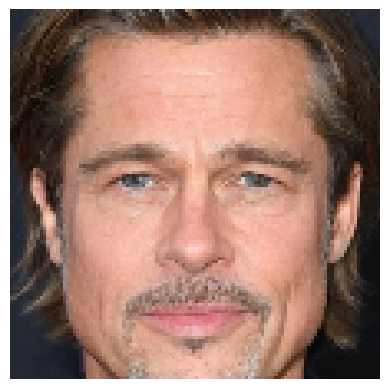

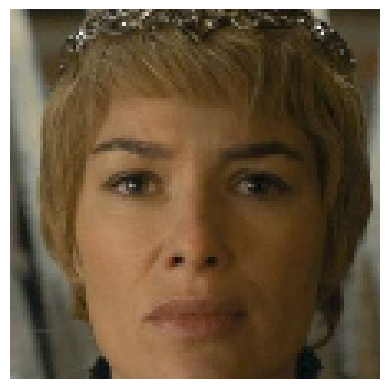

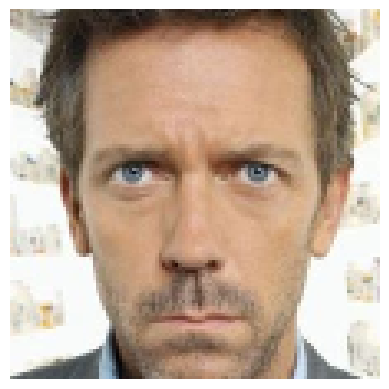

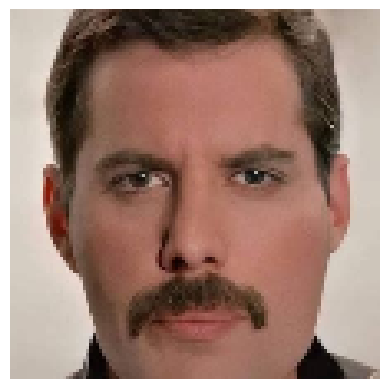

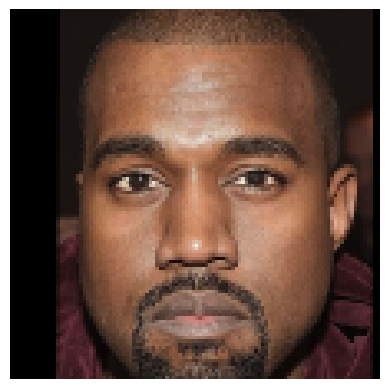

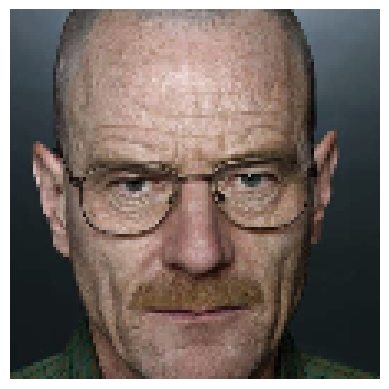

In [48]:
for img in alligned_real_images:
    display_image(img)

In [49]:
from utils.face_recognition import get_embeddings
from sklearn.preprocessing import normalize

In [55]:
RECOGNITION_MODEL_PATH = "/Users/czyjtu/dev/prompt2avatar/thirdparty/recognition/weights/arcface_r100.pth"
recognition_model = _load_insightface_model(RECOGNITION_MODEL_PATH)
real_image_embeddings = get_embeddings(alligned_real_images, recognition_model)
real_images_embeddings_normalized = normalize(real_image_embeddings)# / np.linalg.norm(real_image_embeddings, axis=1)[:, None]

100%|██████████| 1/1 [00:00<00:00, 10.88it/s]


In [56]:
real_genes_pred = model.forward(th.tensor(real_images_embeddings_normalized).float()).detach().numpy()
# clip to 0 - 1 range 
# real_genes_pred_clipped = np.clip(real_genes_pred, 0, 1)
save_predicitons(real_genes_pred, scaler_x, EXPERIMENT_DIR / 'real_faces_sample_mlp_embeddings', "easy")

100%|██████████| 1/1 [00:00<00:00, 27.89it/s]


In [57]:
real_genes_pred.min(), real_genes_pred.max()

(-0.114624165, 0.78775805)

In [58]:
X_pred.min(), X_pred.max()

(-0.003352243, 1.0217135)

### Brad pit 
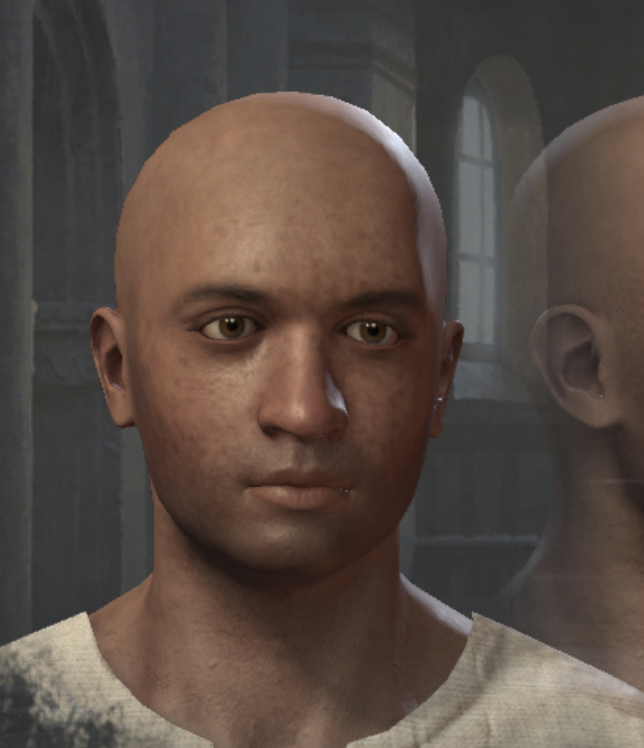

## dr.house 
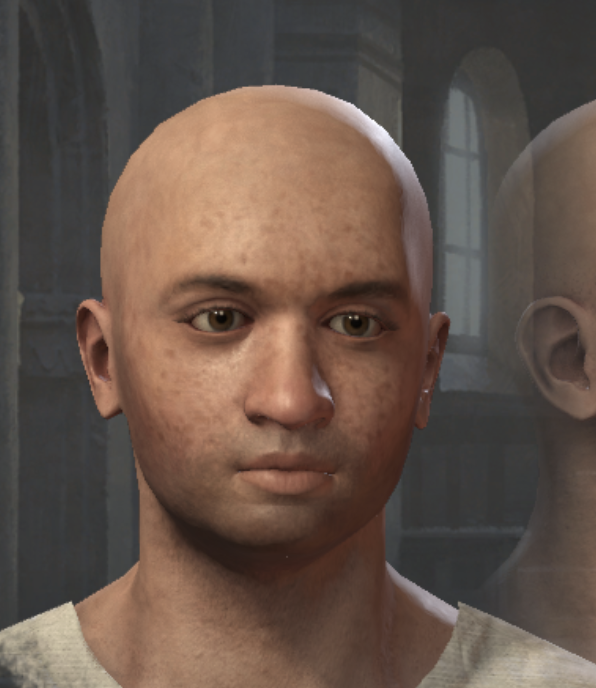

## freddie mercury 
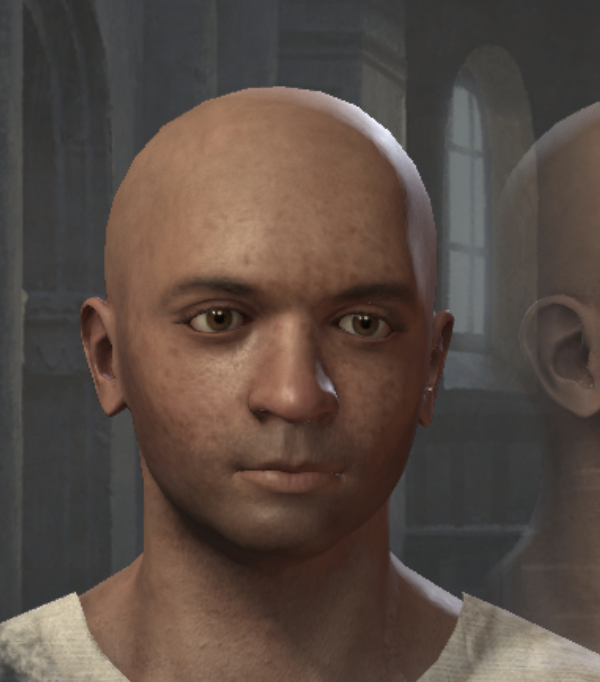

## kanye west
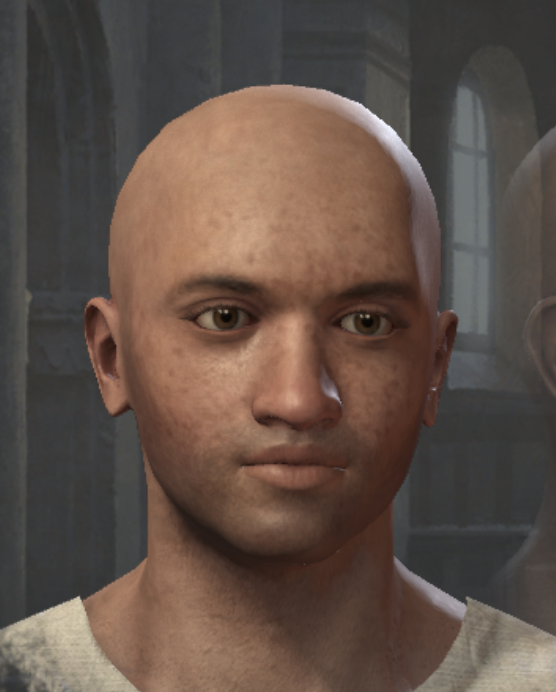

## walter white 
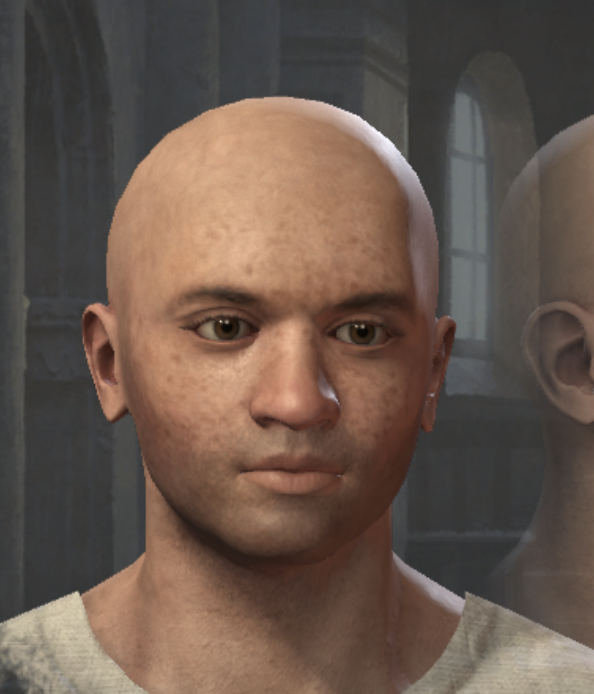

# brudnopis

### generate dnas with linear mutations 

In [25]:
dataset_dna_template

{'hair_color[0]': 93,
 'hair_color[1]': 220,
 'hair_color[2]': 93,
 'hair_color[3]': 220,
 'skin_color[0]': 131,
 'skin_color[1]': 154,
 'skin_color[2]': 131,
 'skin_color[3]': 154,
 'eye_color[0]': 87,
 'eye_color[1]': 218,
 'eye_color[2]': 87,
 'eye_color[3]': 218,
 'gene_chin_forward.chin_forward_pos': 127,
 'gene_chin_height.chin_height_pos': 127,
 'gene_chin_width.chin_width_pos': 127,
 'gene_eye_angle.eye_angle_pos': 126,
 'gene_eye_depth.eye_depth_pos': 139,
 'gene_eye_height.eye_height_pos': 115,
 'gene_eye_distance.eye_distance_pos': 132,
 'gene_eye_shut.eye_shut_pos': 131,
 'gene_forehead_angle.forehead_angle_pos': 103,
 'gene_forehead_brow_height.forehead_brow_height_pos': 141,
 'gene_forehead_roundness.forehead_roundness_pos': 162,
 'gene_forehead_width.forehead_width_pos': 127,
 'gene_forehead_height.forehead_height_pos': 125,
 'gene_head_height.head_height_pos': 126,
 'gene_head_width.head_width_pos': 136,
 'gene_head_profile.head_profile_pos': 132,
 'gene_head_top_height

### Create easy dna set 

In [41]:
from collections import defaultdict 
from copy import deepcopy

test_geneset = [
    'gene_forehead_brow_height',
    'gene_jaw_height',
    'skin_color[1]',
]
test_geneset_template = deepcopy(dataset_dna_template)
for gene in test_geneset:
    for k in test_geneset_template.keys():
        if gene in k:
            del test_geneset_template[k]
            print("Deleted: ", k)
            break 

Deleted:  gene_forehead_brow_height.forehead_brow_height_pos
Deleted:  gene_jaw_height.jaw_height_pos
Deleted:  skin_color[1]


In [42]:
test_geneset_dataset = []
hashes = set()
for gene in dataset.dna:
    gene_dict = gene.flatten()
    gene_dict.update(test_geneset_template)
    new_dna = Genes(**Genes.unflatten(gene_dict))
    hash_ = hash(new_dna.to_ck_string())
    if hash_ not in hashes:
        hashes.add(hash_)
        test_geneset_dataset.append(new_dna)

print(f"Length of test geneset dataset: {len(test_geneset_dataset)}")
print(f"duplicates removed: {len(dataset.dna) - len(test_geneset_dataset)}")

Length of test geneset dataset: 30332
duplicates removed: 0


In [46]:
print(len(set(X_test_geneset[:, 0])))
print(len(set(X_test_geneset[:, 1])))
print(len(set(X_test_geneset[:, 2])))


154
129
92


In [47]:
NEW_DATASET_DIR = ROOT_DIR / 'data' / 'dnas_dataset_2024_04_07_genesets' / 'test_geneset'
NEW_DATASET_DIR.mkdir(exist_ok=True, parents=True)
# for i, dna in enumerate(test_geneset_dataset[:15_000]):
#     with open(NEW_DATASET_DIR / f"{i}.txt", "w") as f:
#         f.write(dna.to_ck_string())

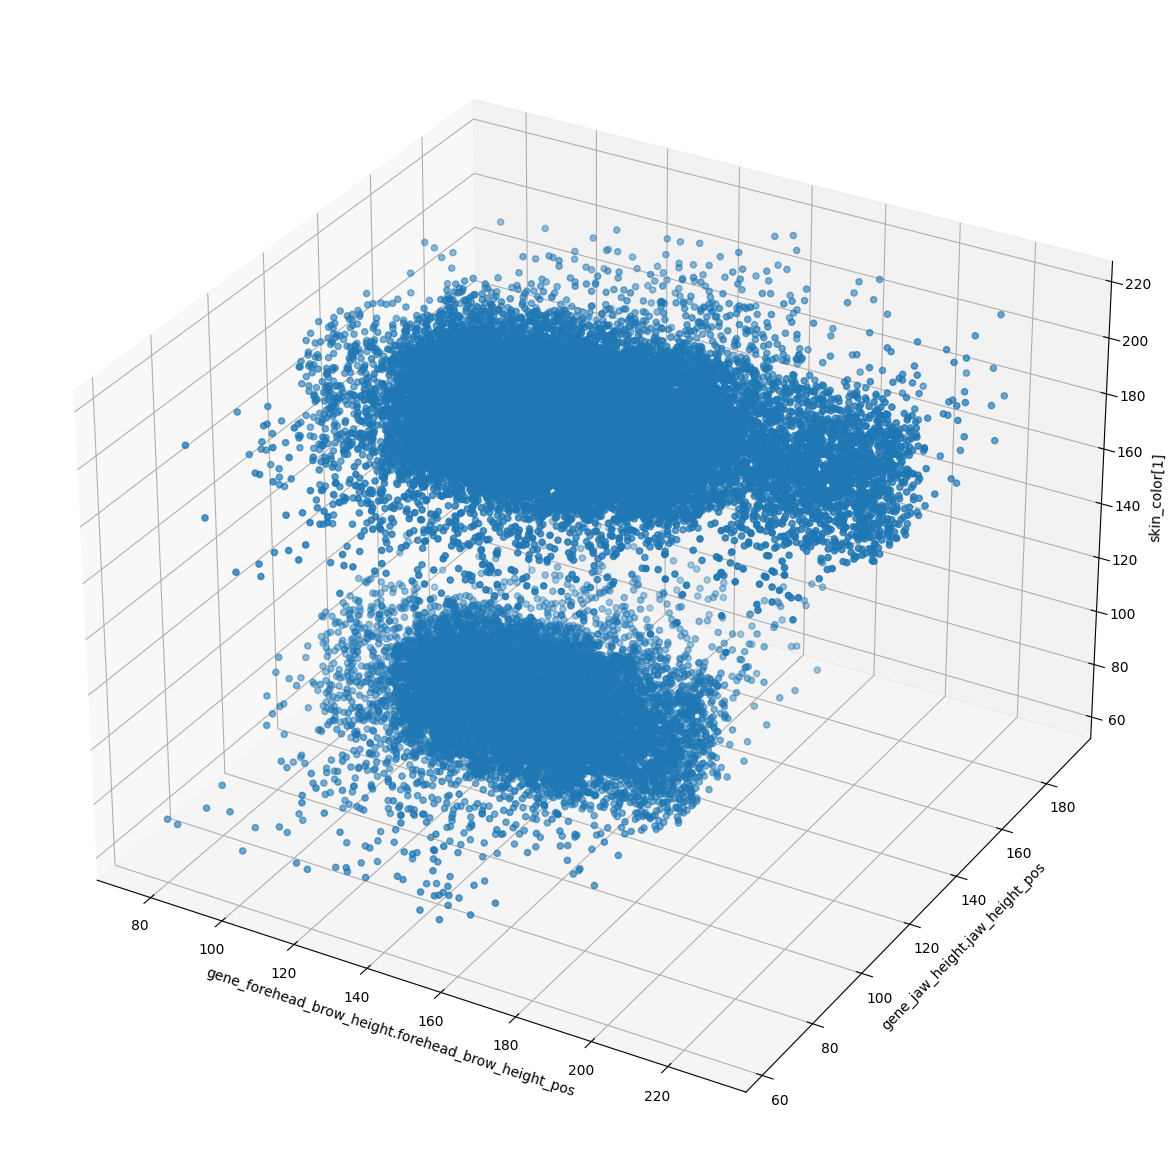

In [34]:
# display 3d distributions of the genes in the test geneset
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

test_geneset_keys = ["gene_forehead_brow_height.forehead_brow_height_pos", "gene_jaw_height.jaw_height_pos", "skin_color[1]"]
X_test_geneset = np.stack([g.asarray(test_geneset_keys) for g in test_geneset_dataset])

# display 3d distributions of the genes in the test geneset
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_geneset[:, 0], X_test_geneset[:, 1], X_test_geneset[:, 2])
ax.set_xlabel(test_geneset_keys[0])
ax.set_ylabel(test_geneset_keys[1])
ax.set_zlabel(test_geneset_keys[2])
plt.show()

In [15]:


gene2dnas = defaultdict(list)
for gene in common_genes:
    gene_min = -255 if gene.split(".")[0] in Genes.model_fields and Genes.model_fields[gene.split(".")[0]].annotation == dict[str, int] else 1
    for i in range(gene_min, 256, 10):
        dna = deepcopy(dataset_dna_template)
        dna[gene] = i
        gene2dnas[gene].append(dna)

In [17]:
save_dir = Path(__name__).resolve().parents[2] / 'data' / 'dnas_2024_04_07'
for gene, dnas in gene2dnas.items():
    gene_dir = save_dir / gene
    gene_dir.mkdir(exist_ok=False, parents=True)
    for i, dna in enumerate(dnas):
        ck_string = Genes(**Genes.unflatten(dna)).to_ck_string()
        dna_fname = f"{i+1}.txt"
        with open(gene_dir / dna_fname, "w") as f:
            f.write(ck_string)
    gene2dnas[gene] = dnas

In [ ]:
# dispaly hisograms for each common gene 
import matplotlib.pyplot as plt
for i, gene in enumerate(common_genes):
    plt.hist(genes_vectorized[:, i])
    plt.title(f"{gene}")
    plt.show()

In [ ]:
import random 
from collections import defaultdict

def create_template_from_genes(genes_list: list[Genes]):
    flattened_dna = [dna.flatten() for dna in genes_list]
    temmplate = defaultdict(list)
    for dna in flattened_dna:
        for key, val in dna.items():
            temmplate[key].append(val)
    avg_template = {key: int(np.mean(val)) for key, val in temmplate.items()}
    return avg_template

random.seed(40)
random.shuffle(genes)
dataset_dna_template = create_template_from_genes(genes)

In [ ]:
# get random image, and gene vector
import random 
import matplotlib.pyplot as plt 

random.seed(114) # is needed to default attributes that are not present in vetorized genes
random_idx = random.randint(0, len(test_images))
image = test_images[random_idx]
gene_vector = Y_test[random_idx]

plt.imshow(image)
plt.show()
# with open(DATA_DIR / "tmp_dna.txt", "w") as f:
#     f.write(Genes.from_array(gene_vector, list(common_genes), dataset_dna_template).to_ck_string())

In [ ]:
from utils.dataset import ProcessedDataset

dataset = ProcessedDataset(Path("/Users/czyjtu/dev/prompt2avatar/data/dataset_2024_04_07_embeddings"))

In [60]:
dataset.paths

array(['/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/0_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/10000_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/10001_resized.png',
       ...,
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/999_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/99_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/9_resized.png'],
      dtype='<U114')

In [62]:
dnas = [open(path.replace("faces_resized", "dna").replace("png", "txt").replace("_resized", ""), "r").read() for path in dataset.paths]

In [63]:
# np.save("/Users/czyjtu/dev/prompt2avatar/data/test_geneset_embeddings/dnas.npy", dnas)

In [ ]:
i = 100
plt.imshow(dataset.alligned_images[i])
path = Path(dataset.paths[i])
plt.show()
plt.imshow(plt.imread("../../" + dataset.paths[i]))

In [ ]:
path.resolve()

## resize images

In [6]:
import os
from PIL import Image
from tqdm import tqdm
from pathlib import Path 

def resize_image(image_path, max_dimension, out_dir):
    # Open the image
    img = Image.open(image_path)
    
    # Convert the image to RGB mode
    rgb_img = img.convert("RGB")
    
    # Resize the image while preserving aspect ratio
    width, height = rgb_img.size
    if width > height:
        new_width = max_dimension
        new_height = int(height * (max_dimension / width))
    else:
        new_width = int(width * (max_dimension / height))
        new_height = max_dimension
    
    resized_img = rgb_img.resize((new_width, new_height))
    
    # Save the resized image with the same name in the same directory
    directory, filename = os.path.split(image_path)
    filename, ext = os.path.splitext(filename)
    new_filename = os.path.join(out_dir, f"{filename}{ext}")
    resized_img.save(new_filename)
    # print(f"Resized image saved as: {new_filename}")

# Example usage
# image_path = DATA_DIR / "0.png"  # Replace with the path to your image
# max_dimension = 430
# resize_image(image_path, max_dimension)

In [8]:
for path in tqdm(sorted(list(Path("/Users/czyjtu/dev/MP2023/results_medium_geneset").rglob("*.png")))):
    resize_image(path, 430, "/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/medium_geneset/faces_resized")

100%|██████████| 30332/30332 [43:39<00:00, 11.58it/s] 
